In [23]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import graphviz

In [24]:
def f(x):
    return 3*x**2 - 4*x + 5

f(3.0)

20.0

In [25]:
#Return evenly spbced vblues within b given interval.
#start, stop, step
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

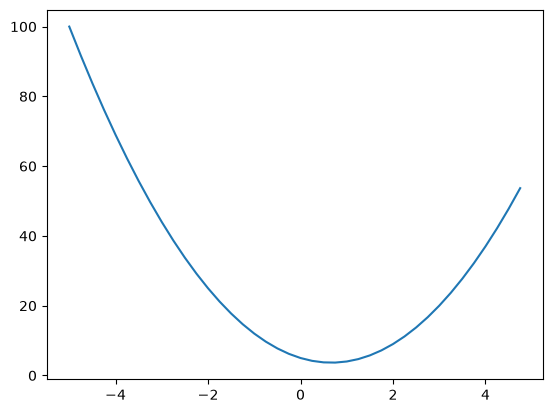

In [26]:
# Plot y versus x as lines and/or markers.
plt.plot(xs, ys)

In [27]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        # gradient
        self.grad = 0
        # by default, don't do anything --> idk what lambda means
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, label={self.label})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad = out.grad
            other.grad = out.grad

        out._backward = _backward

        return out
        
    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad = out.grad * other.data
            other.grad = out.grad * self.data

        out._backward = _backward
        
        return out
    
    def tanh(self):
        x = self.data
        t = (math.exp(2 * x) - 1) / (math.exp(2 * x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad = (1 - t ** 2) * out.grad

        out._backward = _backward
        

        return out

In [28]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'output'
L


Value(data=-8.0, label=output)

In [29]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')

        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [30]:
def lol():

    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'output'

    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0 + h, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'output'

    L2 = L.data

    print((L2 - L1)/h)

lol()

-4.000000000008441


In [31]:
L.grad = 1
d.grad = f.data
f.grad = d.data
e.grad = f.data
a.grad = f.data * b.data
b.grad = f.data * a.data
c.grad = f.data

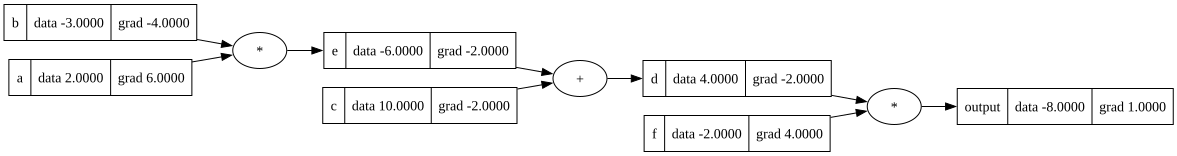

In [32]:
draw_dot(L)


In [33]:
step_size = 0.01

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

L.label = 'output'
L

Value(data=-7.286496, label=output)

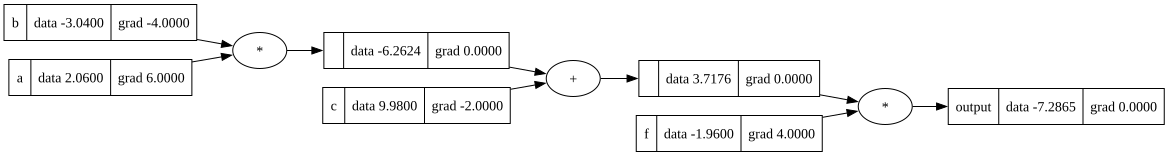

In [34]:
draw_dot(L)

In [35]:
# inputs x1, x2

x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
b = Value(6.8813735870195432, label = 'b')

x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'; o.grad = 1.0

o

Value(data=0.7071067811865476, label=o)

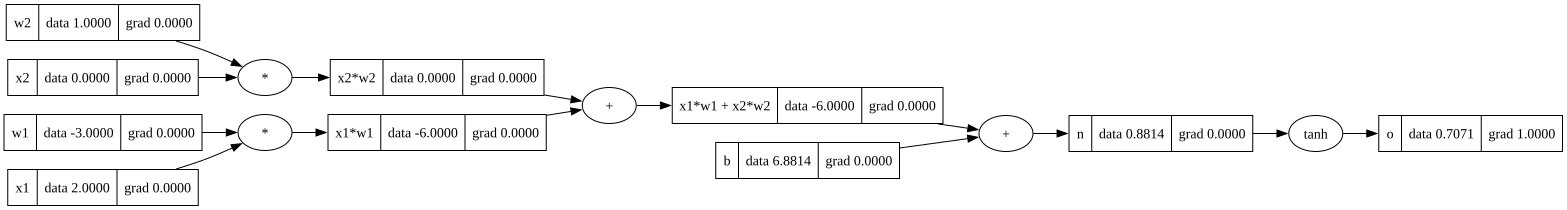

In [36]:
draw_dot(o)

## Manual Backprop

In [37]:
o.grad = 1.0
#n.grad = 1.0 - (n.tanh().data)**2
x1w1x2w2.grad = n.grad
b.grad = n.grad
w1.grad = x1w1x2w2.grad * x1.data
w2.grad = x1w1x2w2.grad * x2.data

In [38]:
step_size = 0.01

n.data += n.grad * step_size
w1.data += w1.grad * step_size
w2.data += w2.grad * step_size

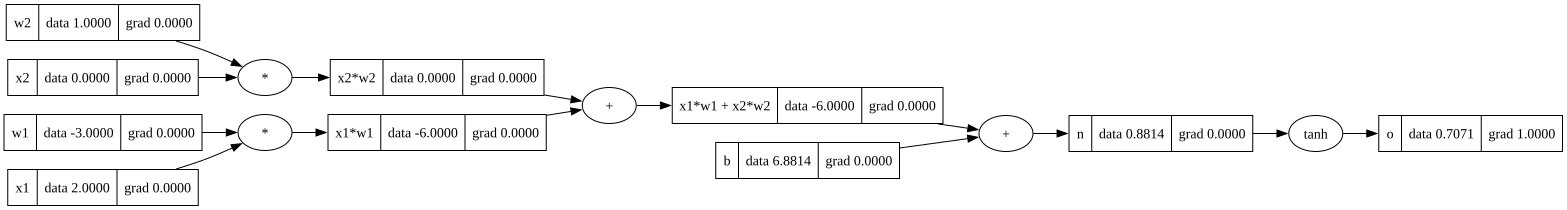

In [39]:
draw_dot(o)

## Automatic Backprop by Calling _backward

In [40]:
o._backward()

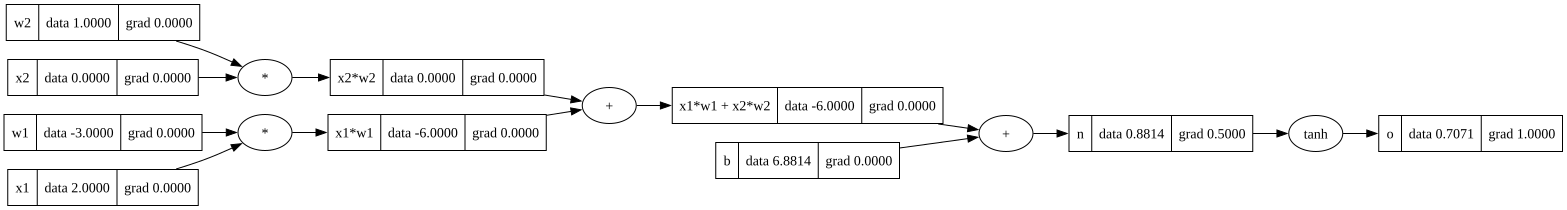

In [41]:
draw_dot(o)

In [42]:
n._backward()
b._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
x1._backward()
w1._backward()
x2._backward()
w2._backward()